$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.8

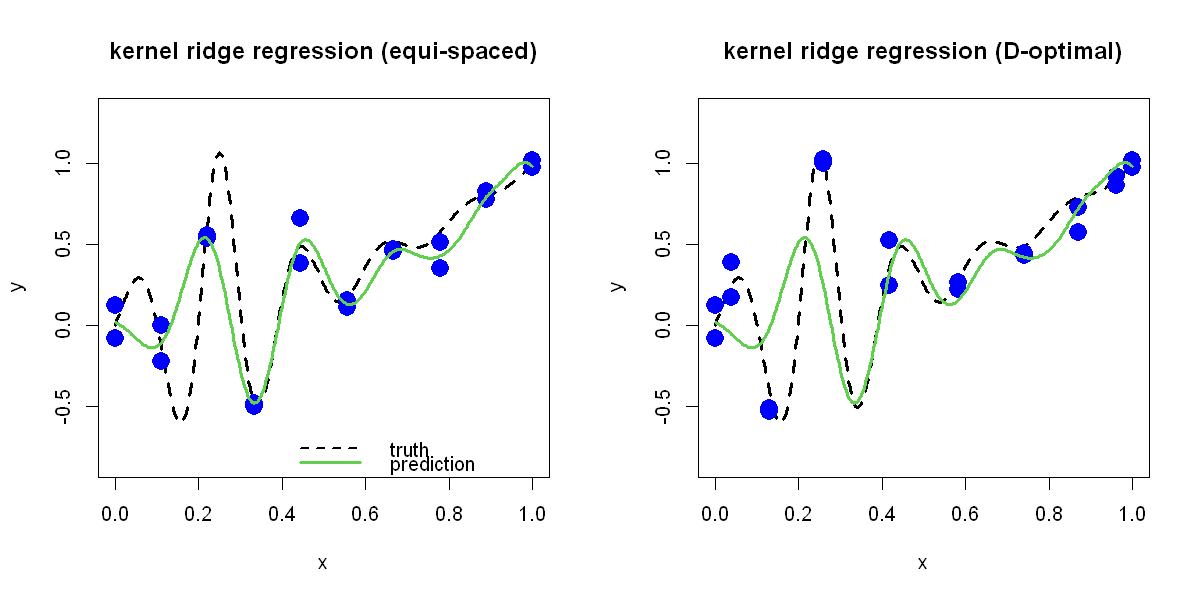

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 背景信息

再次采用上一节数据集 $\{(x_{i},y_{i})\}_{i=1}^{20}$,该数据由一维函数 $$h(x)=\frac{\sin(10\pi x)}{1+64(x-.25)}+x^{2},x\in[0,1]$$ 生成.本节选用高斯核函数 $K(u,v)=\exp(-(u-v)^{2}/\theta^{2})$.通过最小化 MSCV 或 GCV 估计正则化参数 $\lambda$ 与核超参数 $\theta$,两种准则得到的最优参数一致:等间距测点对应的估计值为 $\widehat{\lambda}=0.038$,$\widehat{\theta}=0.080$;九次多项式 D 最优测点对应的估计值为 $\widehat{\lambda}=0.036$,$\widehat{\theta}=0.079$.两组核岭回归预测曲线绘制于图 2.8,拟合效果显著优于图 2.6,图 2.7 中的多项式回归模型.

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 指令

创建画布宽 10 英寸,高 5 英寸.将画布分为 1x2.

```r
options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))
```

创建函数 $$h(x)=\frac{\sin(10\pi x)}{1+64(x-.25)}+x^{2},x\in[0,1]$$,令其为 `f`.取 $[0,1]$ 上的 301 个点,令其为 `test`.计算 301 个点中每一点对应的函数值,令其为 `true`.从 $[0,1]$ 中等距取 10 个点作为观测点,连续取两次组成 `D`.设定种子为 `5`,在均值为 0,标准差为 `.1` 的正态分布中随机取 `20` 个值,令其为 `e`.叠加到观测点对应的真实函数值上作为含噪声的观测值,令其为 `y`.

```r
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
re=2
D=((1:n)-1)/(n-1)
D=rep(D,re)
set.seed(5)
e=rnorm(n*re,sd=.1)
y=f(D)+e
```

创建 `MSCV` 函数用于优化,传入的向量 `para` 中第一项为 `theta`,第二项为 `lam`.使用公式 $$K(u,v)=\exp(-(u-v)^{2}/\theta^{2})$$ 计算高斯核函数,令其为 `R`.使用公式 $$\mathrm{CV}_{i}=\frac{((\boldsymbol{K}+\lambda\boldsymbol{I})^{-1})_{i}\boldsymbol{y}}{((\boldsymbol{K}+\lambda\boldsymbol{I})^{-1})_{ii}},$$ $$\mathrm{MSCV}=\sum_{i=1}^{n}\mathrm{CV}_{i}^{2}/n$$ 计算 MSCV,再取对数使其尺度更平滑利于优化,令其为 `val`.使用 `optim` 函数优化 `MACV`,其中初始猜测值为 `(,1.,1)`,参数优化下界为 `(.05,.001)`,上界为 `(1,1)`,使用带边界约束的拟牛顿优化算法 `L-BFGS-B` 优化.将优化结果赋回 `theta` 与 `lam`.

```r
E=abs(outer(D,D,"-"))
MSCV=function(para){
  theta=para[1]
  lam=para[2]
  R=exp(-(E/theta)^2)
  Rinv=solve(R+lam*diag(n*re))
  cv=c(Rinv%*%y)/diag(Rinv)
  val=log(mean(cv^2))
  return(val)
}
a=optim(c(.1,.1),MSCV,lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
theta=a$par[1]
lam=a$par[2]
print("MSCV:")
theta;lam
```

创建 `RCV` 函数用于优化,其核心公式变为 $$\mathrm{CV}_{i}=\frac{((\boldsymbol{K}+\lambda\boldsymbol{I})^{-1})_{i}\boldsymbol{y}}{\overline{(\boldsymbol{K}+\lambda\boldsymbol{I})^{-1}}},$$ $$\mathrm{MSCV}=\sum_{i=1}^{n}\mathrm{CV}_{i}^{2}/n,$$ 其余同 MSCV.

```r
GCV=function(para){
  theta=para[1]
  lam=para[2]
  R=exp(-(E/theta)^2)
  Rinv=solve(R+lam*diag(n*re))
  cv=c(Rinv%*%y)/mean(diag(Rinv))
  val=log(mean(cv^2))
  return(val)
}
a=optim(c(.1,.1),GCV,lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
theta=a$par[1]
lam=a$par[2]
print("GCV:")
theta;lam
```

观察两种准则的最优参数输出结果得知其优化效果一致,故不妨使用 GCV 准则.重新计算高斯核函数.使用公式 $$\widehat{\boldsymbol{c}}=(\boldsymbol{R}-\lambda\boldsymbol{I})^{-1}\boldsymbol{y}$$ 求解核岭回归系数,令其为 `coef`.使用公式 $$\widehat{y}(\boldsymbol{x})=\boldsymbol{r}(\boldsymbol{x})'\widehat{\boldsymbol{c}}$$ 计算最终预测值,令其为 `pred`.绘制真实函数图像,其中曲线类型为光滑曲线,$x$ 轴标注为 `x`,$y$ 轴标注为 `y`,线宽为 3,曲线类型为虚线,$y$ 轴显示范围为 $[\min(y)-.25,\max(y)+.25]$,主标题为 `kernel ridge regression (equi-spaced)`.叠加观测点,其中点的类型为实心圆点,放缩系数为 2,颜色为蓝色.叠加预测曲线,其中曲线颜色为绿色,线宽为 3.添加图例,位置在右下角,图例内容为 `truth` 与 `prediction`,曲线类型,颜色,线宽与之对应,不添加图例边框.

```r
R=exp(-(E/theta)^2)
coef=solve(R+lam*diag(n*re),y)
R_pred=exp(-(outer(test,D,"-")/theta)^2)
pred=R_pred%*%coef
plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=2,ylim=c(min(true)-.25,max(true)+.25),main="kernel ridge regression (equi-spaced)")
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred,col=3,lwd=3)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n")
```

将 `test` 的范围放缩至 $[-1,1]$,封装成数据框命名为 `cand_df`.使用 R 包 `AlgDesign` 中的 `optFederov` 函数,通过实验设计选取观察点,其中公式为 9 次多项式,实验次数为 `n`,候选集为 `cand_df`,要求精确设计(即给出每个点实验次数的具体次数而不是概率),返回列表命名为 `a`.取其 `design` 数据框中的第一列为最终选取的 10 个观察点.重复选 2 次,将取值范围还原回 $[0,1]$,令其为 `D`.将噪声加到 `f(x)` 上组成带有噪声的观测值,令其为 `y`.绘图要求同上,只是主标题变为 `kernel ridge regression (D-optimal)`.将画布还原回 1x1.

```r
cand_df=data.frame(x=2*test-1)
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
D=rep(c(a$design[,1]),re)
D=(D+1)/2
y=f(D)+e
plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=2,ylim=c(min(true)-.25,max(true)+.25),main="kernel ridge regression (D-optimal)")
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred,col=3,lwd=3)
par(mfrow=c(1,1))
```

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

## 最终效果

[1] "MSCV:"


[1] 0.08014703

[1] 0.03751621

[1] "GCV:"


[1] 0.08036682

[1] 0.03750699

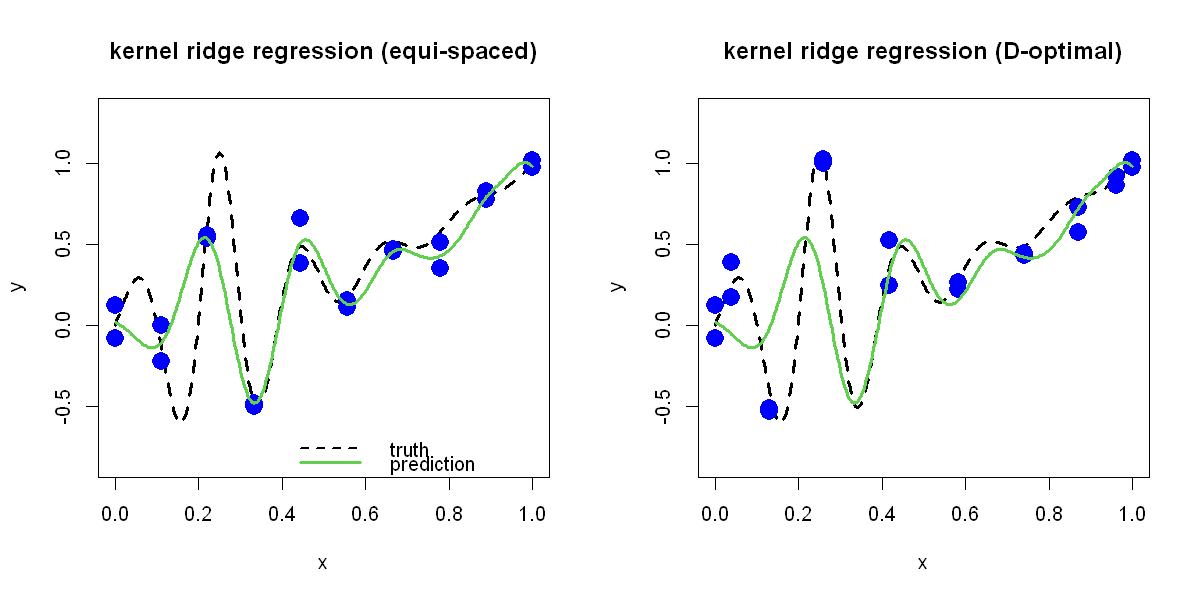

In [1]:
# 图 2.8

options(repr.plot.width=10,repr.plot.height=5)
par(mfrow=c(1,2))

f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=seq(0,1,length=301)
true=f(test)
n=10
re=2
D=((1:n)-1)/(n-1)
D=rep(D,re)
set.seed(5)
e=rnorm(n*re,sd=.1)
y=f(D)+e

## MSCV

E=abs(outer(D,D,"-"))
MSCV=function(para){
  theta=para[1]
  lam=para[2]
  R=exp(-(E/theta)^2)
  Rinv=solve(R+lam*diag(n*re))
  cv=c(Rinv%*%y)/diag(Rinv)
  val=log(mean(cv^2))
  return(val)
}
a=optim(c(.1,.1),MSCV,lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
theta=a$par[1]
lam=a$par[2]
print("MSCV:")
theta;lam

## GCV

GCV=function(para){
  theta=para[1]
  lam=para[2]
  R=exp(-(E/theta)^2)
  Rinv=solve(R+lam*diag(n*re))
  cv=c(Rinv%*%y)/mean(diag(Rinv))
  val=log(mean(cv^2))
  return(val)
}
a=optim(c(.1,.1),GCV,lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
theta=a$par[1]
lam=a$par[2]
print("GCV:")
theta;lam

R=exp(-(E/theta)^2)
coef=solve(R+lam*diag(n*re),y)
R_pred=exp(-(outer(test,D,"-")/theta)^2)
pred=R_pred%*%coef
plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=2,ylim=c(min(true)-.25,max(true)+.25),main="kernel ridge regression (equi-spaced)")
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred,col=3,lwd=3)
legend("bottomright",legend=c("truth","prediction"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n")

## D 最优测点

cand_df=data.frame(x=2*test-1)
library(AlgDesign)
a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
D=rep(c(a$design[,1]),re)
D=(D+1)/2
y=f(D)+e
plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=2,ylim=c(min(true)-.25,max(true)+.25),main="kernel ridge regression (D-optimal)")
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,pred,col=3,lwd=3)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$